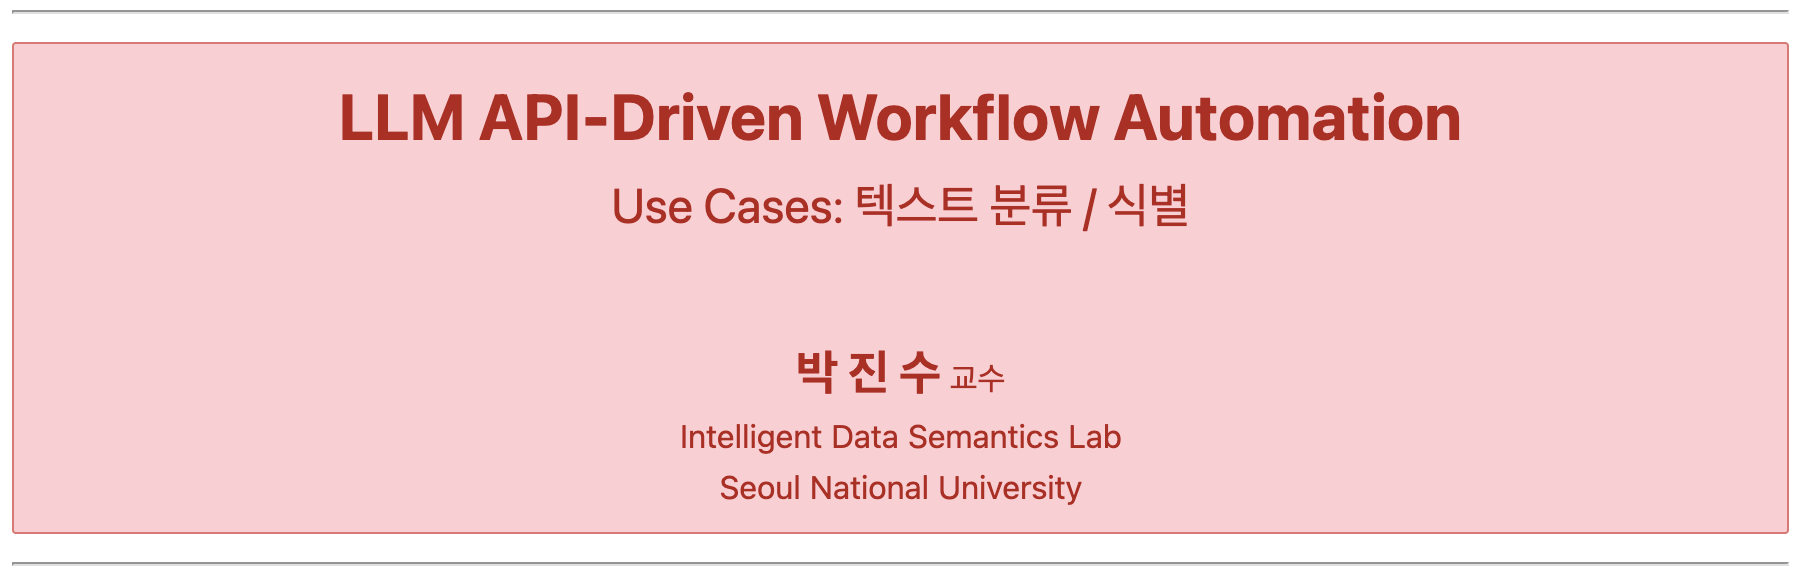

- - -    

- 본 자료는 강의를 위한 목적으로 제작되었습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

> 파이썬 입문자라면, <http://youtube.com/@myontology>의 **[[학습 프로그램]](https://www.youtube.com/@myontology/courses)** 탭을 활용해 보세요. 기초부터 차근차근 배울 수 있는 파이썬 강의 영상이 준비되어 있어 필요한 내용을 쉽고 빠르게 학습할 수 있습니다.

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#도우미-함수-가져오기" data-toc-modified-id="도우미-함수-가져오기-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>도우미 함수 가져오기</a></span></li><li><span><a href="#리뷰-분류기" data-toc-modified-id="리뷰-분류기-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>리뷰 분류기</a></span></li><li><span><a href="#고객-요청-분류" data-toc-modified-id="고객-요청-분류-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>고객 요청 분류</a></span></li><li><span><a href="#고객-응대-편지-작성" data-toc-modified-id="고객-응대-편지-작성-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>고객 응대 편지 작성</a></span></li><li><span><a href="#개체-식별" data-toc-modified-id="개체-식별-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>개체 식별</a></span><ul class="toc-item"><li><span><a href="#제조사와-제품-이름-식별" data-toc-modified-id="제조사와-제품-이름-식별-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>제조사와 제품 이름 식별</a></span></li><li><span><a href="#문서-분류" data-toc-modified-id="문서-분류-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>문서 분류</a></span></li><li><span><a href="#명소-및-식당과-카페-표시" data-toc-modified-id="명소-및-식당과-카페-표시-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>명소 및 식당과 카페 표시</a></span></li><li><span><a href="#명소•식당•카페-이름을-각각-분리-추출" data-toc-modified-id="명소•식당•카페-이름을-각각-분리-추출-6.4"><span class="toc-item-num">6.4&nbsp;&nbsp;</span>명소•식당•카페 이름을 각각 분리 추출</a></span></li><li><span><a href="#식별한-개체들로-휴가-계획-세우기" data-toc-modified-id="식별한-개체들로-휴가-계획-세우기-6.5"><span class="toc-item-num">6.5&nbsp;&nbsp;</span>식별한 개체들로 휴가 계획 세우기</a></span></li></ul></li><li><span><a href="#감성-분석" data-toc-modified-id="감성-분석-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>감성 분석</a></span></li><li><span><a href="#Lab:-감성-분석-및-개체-식별" data-toc-modified-id="Lab:-감성-분석-및-개체-식별-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Lab: 감성 분석 및 개체 식별</a></span></li></ul></div>

# 패키지 설치 및 API 설정

In [ ]:
!python -m pip install -qU python-dotenv gdown pandas redlines IPython langchain # YOUR LLM package HERE (e.g., ollama 'langchain[ollama]' mistralai 'langchain[mistralai]' groq 'langchain[groq]' google-genai 'langchain[google-genai]' anthropic 'langchain[anthropic]' openai 'langchain[openai]')
print('--- Installation Completed', '-' * 55, '\n')

In [ ]:
# 방법 1 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

In [1]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

Enter Your LLM API Key:  ········


In [ ]:
# 방법 3 (API Key 명칭 수정 후 사용) - (caution) API 키 노출 주의
import os
os.environ['?????_API_KEY'] = 'YOUR-LLM-API-KEY'

# 도우미 함수 가져오기


In [ ]:
# --- utils.py 다운로드
!gdown 1UHksqU7wivF2308wDwEfz8Jf9-qsWyWi -O utils.py

**<u><font size='+1'>도우미 함수 사용법</font></u>**


**1. get_llm_response**(instruction, user_message, model, messages, **kwargs)
- `instruction`에 시스템 지침을, `user_message`에 사용자 입력을 전달하면 LangChain 기반으로 LLM을 호출해 응답 텍스트를 반환한다.
- `messages`에 LangChain 메시지 객체 리스트(`SystemMessage`, `HumanMessage`, `AIMessage` 등)를 직접 전달할 수도 있다. 이 경우 `instruction`과 `user_message`는 무시된다.
- `model`에 사용할 모델 ID를 전달한다 (예: `'openai:gpt-5.4-mini'`, `'google_genai:gemini-2.5-flash'`, `'anthropic:claude-sonnet-4-5-20250929'`).
    + **<font color='tomato'>이 함수의 기본 모델은 `'google_genai:gemini-3.1-flash-lite'`이다.</font>**
    + LangChain에서 사용할 수 있는 모델 이름(ID)과 형식은 공식 문서에서 확인할 수 있다.
        * https://reference.langchain.com/python/langchain/chat_models/base/init_chat_model
- `**kwargs`로 `temperature`, `max_output_tokens` 등 모델별 추가 파라미터를 전달할 수 있다.
    + 💡 참고: GPT-5를 비롯한 일부 추론 모델은 `temperature` 등 일부 파라미터를 지원하지 않는다.
- Gemini, Claude 등 일부 모델이 반환하는 블록 형태의 응답도 내부에서 자동으로 처리해 순수 텍스트만 반환한다.

**사용 예시**
```python
response = get_llm_response(instruction, user_message) # 기본값이 'google_genai:gemini-3.1-flash-lite'
response = get_llm_response(instruction, user_message, model='google_genai:gemini-3.1-flash-lite')
response = get_llm_response(instruction, user_message, model='openai:gpt-5.4-mini')
response = get_llm_response(instruction, user_message, model='anthropic:claude-haiku-4-5')
```
<br/>

**2. load_doc**(folder, filename)
- `folder`에 파일이 위치한 폴더 경로를, `filename`에 읽어올 파일 이름을 전달하면 텍스트 파일을 읽어 문자열로 반환한다.
- `folder`가 `None`, `''`, 또는 `'.'`이면 현재 작업 디렉터리를 기준으로 파일을 찾는다.

<br/>

**3. print_doc**(folder, filename)
- `folder`와 `filename`을 전달하면 해당 파일을 읽어 내용을 콘솔에 그대로 출력한다.
- 내부적으로 `load_doc`을 호출해 파일을 읽는다.

# 리뷰 분류기

In [ ]:
import gdown

!gdown 1pISI01VMLoI6BZCorGb46JtpsIqk7Dnu -O review-outdoor-foldease.txt
!gdown 16w9OzyV3Fz7iFGk9FRQlfrUwYb7eH8ix -O review-outdoor-breezesleep.txt
!gdown 17MVYXnzpAR8xxXW3p-gnz4V0Svtf3-5E -O review-outdoor-trailtorch500.txt
!gdown 1dKajFJl3UgxG9B3aC0_96y7IXt-v9ZAM -O review-outdoor-inflatotron2000.txt
!gdown 14BpYaEm4JFbLUeLkWdBvD4gvV0Oe4lHA -O review-outdoor-aquavault.txt

In [5]:
from pathlib import Path
from glob import glob
from utils import load_doc

folder = Path.cwd()
reviews = {}
for file in sorted(folder.glob('review-outdoor-*.txt')):
    content = load_doc(folder, file.name)
    reviews[file.name] = content

for name, content in reviews.items():
    print(f'--- {name} ---')
    print(content, '\n\n')

--- review-outdoor-aquavault.txt ---
AquaVault 휴대용 방수 금고는 최근 캠핑이나 야외 활동 중 귀중품을 보관하기 위해 구매한 제품입니다. 사용해 본 결과, 몇 가지 장점에도 불구하고 아쉬운 점들이 있었습니다. 우선 제품의 구조상 부피가 커서 캠핑 짐에 포함하기에 다소 부담스러웠습니다. 사용 중에는 기대했던 것만큼 보안 성능이 뛰어나다고 느껴지지 않아, 귀중품을 완전히 안심하고 맡기기 어려웠습니다. 보관할 때도 부피 때문에 차지하는 공간이 많아 정리하기가 번거로웠습니다. 가장 큰 문제는 기대만큼의 성능을 보여주지 못한다는 점입니다. 마지막으로, 제한적이거나 불충분한 보증 정책 또한 예상치 못한 불편함으로 다가왔고, 이는 제품 사용 경험 전반에 아쉬움을 남겼습니다.

결론적으로, AquaVault 휴대용 방수 금고는 특정 상황에서는 유용할 수 있으나, 전반적인 품질과 편의성을 고려할 때 개선이 필요한 제품이라고 생각됩니다. 


--- review-outdoor-breezesleep.txt ---
BreezeSleep 야외용 침낭은 최근 캠핑이나 아웃도어 활동을 위해 구매한 제품으로, 실제 사용 경험을 공유하고자 합니다. 이 침낭의 가장 큰 장점은 기대 이상의 성능과 훌륭한 가성비입니다. 캠핑 환경에서도 불편함 없이 편안하게 사용할 수 있었고, 필수적인 기능들을 잘 갖추고 있어 아웃도어 활동 시 매우 유용했습니다. 특히 가격 대비 만족도가 높은 점이 매우 인상적이었습니다. 하지만 몇 가지 아쉬운 점도 있었습니다. 우선, 부피가 있어 특정 상황에서는 휴대하기가 다소 불편했습니다. 또한, 유지 및 수리가 어렵거나 비용이 많이 든다는 점도 단점이었습니다. 마지막으로, 사용 후 정리나 보관이 번거롭고 보증 정책이 제한적이라는 점도 아쉬움으로 남습니다. 종합적으로 보면, BreezeSleep 야외용 침낭은 분명 여러 장점을 가진 제품이지만, 일부 단점도 존재하기 때문에 사용자의 환경과 필요에 따라 평가가 달라질 수 있겠습니다. 


-

In [7]:
from utils import get_llm_response

instruction = '''제공되는 사용자 리뷰를 분석하여
아래 목록에서 태그를 선택해 제공하는 것이 당신의 업무입니다.
답변은 글머리 기호 형태로 제공하세요. 아래에 있는 태그 목록에서만 선택해야합니다.

긍정적 태그 vs. 부정적 태그 중 하나만 선택하고 둘 다 선택하지 마세요.
- 가격 대비 좋은 가치 제공 vs. 비용이 너무 많이 듦
- 기대치 보다 더 잘 작동함 vs. 기대치 만큼 잘 작동하지 않음
- 필수 기능 포함 vs. 필수 기능 부족
- 사용하기 쉬움 vs. 사용하기 어려움
- 품질과 내구성이 높음 vs. 품질과 내구성이 떨어짐
- 유지 및 수리가 쉽고 비용이 저렴함 vs. 유지 및 수리가 어렵거나 비용이 많이 듦
- 운반하기 쉬움 vs. 운반하기 어려움
- 보관하기 쉬움 vs. 보관하기 어려움
- 다른 장치나 시스템과 호환됨 vs. 다른 장치나 시스템과 호환되지 않음
- 안전하고 사용자 친화적임 vs. 사용하기에 안전하지 않거나 위험함
- 우수한 고객 지원 vs. 미흡한 고객 지원
- 넉넉하고 포괄적인 보증 vs. 제한적이거나 불충분한 보증
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 각 파일명과 리뷰를 순회하며 사용자 프롬프트로 LLM을 호출하고 결과를 출력한다.

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
else:
    print('!!! 작업을 완료했습니다', '!' * 55)

--- review-outdoor-aquavault.txt ---
- 기대치 만큼 잘 작동하지 않음
- 운반하기 어려움
- 보관하기 어려움
- 품질과 내구성이 떨어짐
- 제한적이거나 불충분한 보증

--- review-outdoor-breezesleep.txt ---
- 가격 대비 좋은 가치 제공
- 기대치 보다 더 잘 작동함
- 필수 기능 포함
- 유지 및 수리가 어렵거나 비용이 많이 듦
- 운반하기 어려움
- 보관하기 어려움
- 제한적이거나 불충분한 보증

--- review-outdoor-foldease.txt ---
- 사용하기 쉬움
- 품질과 내구성이 떨어짐
- 유지 및 수리가 쉽고 비용이 저렴함
- 운반하기 쉬움
- 보관하기 쉬움
- 사용하기에 안전하지 않거나 위험함

--- review-outdoor-inflatotron2000.txt ---
- 사용하기 쉬움
- 품질과 내구성이 떨어짐
- 기대치 만큼 잘 작동하지 않음
- 운반하기 어려움
- 보관하기 어려움

--- review-outdoor-trailtorch500.txt ---
- 가격 대비 좋은 가치 제공
- 기대치 보다 더 잘 작동함
- 필수 기능 포함
- 사용하기 쉬움
- 품질과 내구성이 떨어짐
- 운반하기 어려움
- 보관하기 어려움
- 안전하고 사용자 친화적임

!!! 작업을 완료했습니다 !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


# 고객 요청 분류

In [8]:
instruction = f'''당신은 고객 서비스 부서에서 근무하는 친절한 직원입니다.
고객의 각 문의는 주요 카테고리와 부 카테고리로 분류해야 합니다.
주요 카테고리와 부 카테고리로 구분하여 **코드 블록 없이**, 순수한 json 객체 형식만 출력하세요.

주요 카테고리: 청구, 기술 지원, 계정 관리, 일반 문의

청구의 부 카테고리:
구독 취소 또는 업그레이드
결제 수단 추가
과금에 대한 설명
청구에 대한 이의 제기

기술 지원의 부 카테고리:
일반적인 문제 해결
기기 호환성
소프트웨어 업데이트

계정 관리의 부 카테고리:
비밀번호 재설정
개인정보 업데이트
계정 해지
계정 보안

일반 문의의 부 카테고리:
제품 정보
가격
피드백
서비스 담당자와 연결
'''
user_requests = [
    '노트북에 대해 자세히 알려주세요.',                                            
    '계정을 삭제했으면 합니다. 내 프로필과 나의 모든 사용자 데이터를 삭제해 주시길 원합니다.', 
    '다음 달 요금이 왜 이렇게 많이 나왔는지 설명 부탁드려요.',                  
    '결제 카드 정보를 새로 등록하고 싶어요. 어떻게 하나요?',                  
    '앱이 자꾸 강제 종료돼요. 해결 방법이 있을까요?',                     
    '제 계정에 로그인할 수 없습니다. 비밀번호를 잊어버렸어요.',               
    '프로 플랜으로 업그레이드하고 싶습니다. 안내 부탁드려요.',               
    '앱이 실행되지 않아서 여러 번 재설치해 봤는데 계속 같은 문제가 발생합니다.',   
    '최근 청구 내역에 오류가 있는 것 같습니다. 이의 제기를 하고 싶어요.',     
    '내 정보를 최신 주소와 전화번호로 업데이트하려면 어떻게 해야 하나요?',     
    '계정 보안 설정을 강화하고 싶어요. 2단계 인증이 가능한가요?',        
    '서비스에 대한 피드백을 남기고 싶습니다. 만족도 조사 링크가 있을까요?',  
    '신규 출시된 제품에 대해 자세히 알려주세요.',                
    '고객센터 담당자와 직접 통화할 수 있을까요?',               
    '최근에 받은 소프트웨어 업데이트 이후 앱이 느려졌어요.',        
    "청구서에 표시된 '기타 수수료'가 뭔가요?",              
    '결제 수단으로 페이팔을 추가할 수 있나요?',             
    '서비스를 취소하고 환불을 받고 싶어요.'               
]

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 각 사용자 문의를 순회하며 시스템 프롬프트와 함께 LLM을 호출하고 결과를 출력한다.

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
else:
    print('!!! 작업을 완료했습니다', '!' * 55)    

{
  "주요 카테고리": "일반 문의",
  "부 카테고리": "제품 정보"
}
---------------------------------------------------------------------------
{
  "주요 카테고리": "계정 관리",
  "부 카테고리": "계정 해지"
}
---------------------------------------------------------------------------
{
  "주요 카테고리": "청구",
  "부 카테고리": "과금에 대한 설명"
}
---------------------------------------------------------------------------
{
  "주요 카테고리": "청구",
  "부 카테고리": "결제 수단 추가"
}
---------------------------------------------------------------------------
{
  "주요 카테고리": "기술 지원",
  "부 카테고리": "일반적인 문제 해결"
}
---------------------------------------------------------------------------
{
  "주요 카테고리": "계정 관리",
  "부 카테고리": "비밀번호 재설정"
}
---------------------------------------------------------------------------
{
  "주요 카테고리": "청구",
  "부 카테고리": "구독 취소 또는 업그레이드"
}
---------------------------------------------------------------------------
{
  "주요 카테고리": "기술 지원",
  "부 카테고리": "일반적인 문제 해결"
}
---------------------------------------------------------------------------
{
  

# 고객 응대 편지 작성

In [ ]:
import gdown

!gdown 1BOM9s3b6O-WZpCH2ocHETD_DKqd39XF7 -O customer-review-1.txt
!gdown 1OH0AVwn2_2kf4roiQLB47UBE4_LMWIcl -O customer-review-2.txt
!gdown 1Lh33XXzV6RnVQajrtHlIHVAJ539MINYr -O customer-review-3.txt
!gdown 1FEn-6pBc_1G54U8BZ2-6tBwh0rBcoCLA -O customer-review-4.txt
!gdown 1RJ_WUAKn5QUNRMkiJVwacha8l7UJ7rEh -O customer-review-5.txt

In [10]:
folder = Path.cwd()
reviews = {}
for file in sorted(folder.glob('customer-review-*.txt')):
    content = load_doc(folder, file.name)
    reviews[file.name] = content

for name, content in reviews.items():
    print(f'--- {name} ---')
    print(content, '\n\n')

--- customer-review-1.txt ---
최근에 블루투스 무선 이어폰을 새로 구입해서 몇 주간 써보고 있습니다. 이전까지는 유선 이어폰만 쓰다가 처음으로 무선 제품을 써봤는데, 확실히 움직임이 자유로워져서 일상생활이 한결 편해졌어요. 특히 출퇴근 지하철에서 가방 끈이나 옷깃에 걸리지 않아 너무 좋더라고요.

음질은 특별히 뛰어나다고 말하기는 어렵지만, 평소 음악이나 팟캐스트를 듣는 제 용도로는 무난하게 괜찮았습니다. 통화 품질도 만족스러워서 시끄러운 길거리에서도 상대방이 제 목소리를 잘 듣는다고 하더군요. 이어폰의 착용감 역시 마음에 들어서 오래 착용해도 귀가 아프거나 불편하지 않았습니다.

하지만 아쉬운 점이라면, 터치식 버튼이 가끔 제대로 작동하지 않거나 오작동할 때가 있다는 거예요. 한 번은 이어폰을 살짝 조정하려고 만졌다가 갑자기 음악이 멈춰버려 당황한 적도 있었어요. 배터리 성능은 나쁘지 않아서, 충전 케이스를 휴대하고 다니면 하루 종일 문제없이 사용할 수 있었습니다.

제품의 디자인은 심플하고 예쁘지만, 이어폰 표면이 매끄러워서 손에서 미끄러지기 쉽다는 점은 살짝 아쉬웠습니다. 그래도 첫 무선 이어폰으로서 전반적으로 만족스럽고, 앞으로의 내구성만 믿을 수 있다면 주변에도 추천할 만한 제품입니다. 배송 속도는 적당했고, 포장 상태도 좋았습니다. 


--- customer-review-2.txt ---
지난달에 무선 진공청소기 최신 모델을 약 250,000원 정도에 구입했습니다. 비슷한 가격대 제품들이 많아서 고민을 좀 했지만, 주변의 추천을 받아 선택했어요. 우선 디자인이 슬림하고 가벼워서 청소할 때 손목에 부담이 덜 가는 점이 마음에 들었습니다. 흡입력도 기대 이상이라서 평소에 잘 빨리지 않던 카펫의 먼지까지 말끔히 처리할 수 있었어요. 다만 배터리 사용시간이 조금 아쉽더라고요. 한 번 충전하면 일반 모드로는 40분 정도 사용할 수 있다고 하는데, 실제 사용해보니 터보 모드를 쓰면 15분 정도밖에 지속되지 않아 넓은 집에서는 여러 번 

In [11]:
instruction = '''당신은 고객 서비스 담당 부서에서 일하는 아주 친절한 직원입니다.
귀하의 임무는 소중한 고객에게 이메일 답장을 작성해서 보내는 것입니다.
고객의 이메일을 받아, 그들의 제품 평가에 감사하는 답장을 작성하세요.
제품 평가의 감정이 긍정적이거나 중립적이라면, 그들의 평가에 감사하다고 답장하세요.
만약 감정이 부정적이라면, 정중하게 사과하고 고객 서비스에 연락할 것을 제안하세요.
제품 평가에서 구체적인 내용을 사용하는 것을 잊지 마세요.
간결하고 전문적인 어조로 작성하세요. 
이메일을 '고객 담당 AI 직원'으로 서명하세요.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 각 리뷰를 순회하며 시스템 프롬프트와 함께 LLM을 호출해 답장 이메일을 생성하고 출력한다.

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
else:
    print('!!! 오늘 해야 할 업무 모두 완료 했습니다.', '!' * 55)

--- customer-review-1.txts---
안녕하세요, 고객님.

저희 제품을 구매해주시고 소중한 시간을 내어 상세한 후기를 남겨주셔서 진심으로 감사드립니다.

우선, 유선 이어폰에서 무선 이어폰으로 처음 넘어가시는 과정에서 저희 제품이 고객님의 출퇴근 길을 더욱 편리하게 만들어 드렸다니 매우 기쁩니다. 특히 통화 품질과 편안한 착용감, 그리고 배터리 성능에 만족하셨다는 점을 알게 되어 보람을 느낍니다.

동시에, 터치식 버튼의 오작동 문제와 매끄러운 표면으로 인한 사용상의 불편함을 겪으셨다는 점은 안타깝게 생각합니다. 고객님께서 겪으신 터치 오작동의 경우, 제품의 결함인지 혹은 설정상의 문제인지 확인이 필요할 것 같습니다. 

제품 사용에 지속적으로 어려움이 있으시다면, 언제든지 저희 고객 서비스 센터(또는 고객 지원 게시판)로 연락해 주시기 바랍니다. 기술적인 도움을 드리거나 제품 점검을 통해 문제를 해결할 수 있도록 정성을 다해 지원해 드리겠습니다.

소중한 의견을 바탕으로 앞으로 더욱 개선된 제품을 선보일 수 있도록 노력하겠습니다. 다시 한번 귀한 후기 남겨주셔서 감사합니다.

고객 담당 AI 직원 드림

--- customer-review-2.txts---
안녕하세요, 고객님.

저희 제품을 구매해주시고 소중한 후기를 남겨주셔서 진심으로 감사드립니다.

먼저, 저희 무선 진공청소기의 슬림한 디자인과 가벼운 무게, 강력한 흡입력 및 편리한 LED 조명 기능에 만족해주셨다니 무척 기쁩니다. 빠른 배송과 서비스센터의 신속한 대응에 대해서도 좋게 평가해주셔서 큰 보람을 느낍니다.

말씀해주신 터보 모드 시의 배터리 지속 시간과 관절 부위의 내구성에 대한 의견은 향후 제품 개선을 위한 중요한 자료로 활용하겠습니다. 고객님께서 제안해주신 부분들을 깊이 새겨 더 나은 제품을 만들 수 있도록 노력하겠습니다.

혹시라도 제품 사용 중 추가적인 불편 사항이나 기술적인 도움이 필요하시다면, 언제든 저희 고객 서비스 센터로 연락해주시기 바랍니다. 고객님의 의견에

# 개체 식별 

## 제조사와 제품 이름 식별

In [ ]:
import gdown

!gdown 1qhtBQOIdbWvl8rBmp5oLNKzTlHuwYUjy -O review-product-1.txt
!gdown 1DFBHSO0n6JEyOo-FfqROmx4Jm0nznXEN -O review-product-2.txt
!gdown 1aHha_ElcaU3UGFBKL6d7Y4zFeWAI948k -O review-product-3.txt
!gdown 1ZL1Kh3BZk4ZbB7taIashY7uXB4B7rL5u -O review-product-4.txt
!gdown 1WEu4DanNvAmStqaviE-Nk9E-P-J9QMmQ -O review-product-5.txt

In [13]:
folder = Path.cwd()
reviews = {}
for file in sorted(folder.glob('review-product-*.txt')):
    content = load_doc(folder, file.name)
    reviews[file.name] = content

for name, content in reviews.items():
    print(f'--- {name} ---')
    print(content, '\n\n')
else:
    print('!!! 작업을 완료했습니다', '!' * 55)      

--- review-product-1.txt ---
최근에 스포츠웨어에서 출시한 스마트피트 러닝화를 구입했습니다. 이 신발은 정말 편안하면서도 발의 움직임을 잘 지원해주는 것 같아요. 특히, 장시간 착용해도 발이 피로하지 않다는 점이 마음에 들어요. 디자인도 세련되어서 일상복에도 잘 어울리네요. 하지만 가격이 다소 높은 편이라, 예산을 고려해야 할 것 같아요. 스포츠웨어는 이번에도 기대를 저버리지 않는 제품을 만든 것 같습니다. 전반적으로 매우 만족스러운 구매였습니다! 


--- review-product-2.txt ---
어반보이스 사의 라이트패널 무선 조명을 사용해봤어요. 밝기 조절이 섬세하고, 설치도 간편해서 인테리어에 딱입니다. 무선이라 장소 제약 없이 활용할 수 있어 만족스럽네요. 어반보이스가 조명 분야에서 다시 한번 기술력을 보여줬어요. 


--- review-product-3.txt ---
최근에 노바코어에서 출시한 에어핏 블루투스 이어폰을 구매했어요. 음질이 생각보다 훨씬 좋아서 음악 감상이 정말 즐겁습니다. 통화 품질도 훌륭하고, 배터리도 오래가요. 노바코어 제품은 항상 믿고 쓰게 되는 것 같아요. 


--- review-product-4.txt ---
트레일메이드에서 만든 익스트림 백팩을 써봤는데요, 수납공간이 다양하고 무게 분산이 잘 되어 있어 등산에 아주 적합합니다. 방수 기능도 뛰어나서 비 오는 날에도 문제 없이 썼습니다. 디자인도 감각적이라서 여행용으로도 손색이 없네요. 


--- review-product-5.txt ---
이번에 코지하우스의 울트라소프트 전기담요를 구매했습니다. 겨울 캠핑 갈 때 유용하게 쓰고 있어요. 전원 온도 조절이 직관적이고, 안전장치도 잘 되어 있어 안심됩니다. 코지하우스는 따뜻함을 잘 아는 브랜드 같아요. 


!!! 작업을 완료했습니다 !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [15]:
from IPython.display import Markdown

instruction = '''당신의 업무는 주어진 개체(entity)를 추출하는 것입니다.
제품 리뷰 텍스트에서 다음 항목을 식별하세요.
- 그 제품을 만든 회사
- 평가자가 구매한 제품

답변은 'brand'와 'item'을 제목으로 하는 마크다운 표 형식으로 작성하세요.
정보가 없다면 값(value)으로 'unknown'을 사용하세요.
답변은 가능한 짧게 해주세요.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 리뷰 내용 전체를 하나의 문자열로 변환해 LLM에 전달하고 마크다운 표로 출력한다.

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

| brand | item |
| :--- | :--- |
| 스포츠웨어 | 스마트피트 러닝화 |
| 어반보이스 | 라이트패널 무선 조명 |
| 노바코어 | 에어핏 블루투스 이어폰 |
| 트레일메이드 | 익스트림 백팩 |
| 코지하우스 | 울트라소프트 전기담요 |

## 문서 분류

In [ ]:
import gdown

!gdown 1LONQ02StM4ai7M1HQvRMX46HjSC2iL0- -O blog-seoul.txt
!gdown 1YMYE6XkuWdcf6HDQ6bQ550JxsSRuMYK0 -O blog-madrid.txt
!gdown 1tR2APmqfnpzktjXLumjNUTbjfTwQW2wz -O blog-paris.txt
!gdown 1ozj1ayz0n6SL2uc_UkIn4VkcnwPewbzA -O blog-kyoto.txt
!gdown 1ohy4K2-UYHTtabveCDx3e_9z8_kMc30g -O blog-reykjavik.txt
!gdown 1vb_VwKCcKLWzyXNFE879hlG1oJrLj5L3 -O blog-new-york.txt
!gdown 1GTHZrKl80fRfztN1G9eH0Emiak2zhD45 -O blog-rio-de-janeiro.txt
!gdown 1VHnWbJpf9MK3xXkLyYYmADTZnlUMtjGw -O blog-cape-town.txt
!gdown 1K8dtwHfWNtL9nwY4PIffdfykzvsObQOj -O blog-sydney.txt
!gdown 1lYFsAFrCSvpQ8TiXBCGWh_LN3Yw8qsx5 -O blog-toronto.txt

In [19]:
instruction = '''
'O' 또는 'X'으로만 답변하시고 그 외 어떤 말도 하지 마세요.

이 블로그 글은 지역의 명소와 각 명소 근처의 식당이나 카페를 소개하고 있습니다.

블로그 글:
'''
folder = Path.cwd()
blog_files = []
for file in sorted(folder.glob('blog-*.txt')):
    blog_post = load_doc(folder, file.name)
    response = get_llm_response(instruction, blog_post)

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

    # LLM 응답이 'O'이면 해당 파일명을 목록에 추가한다.  

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

    print(f'{file.name} -> {response}')
else:
    print(f'\n{blog_files}')

blog-cape-town.txt -> O
blog-kyoto.txt -> O
blog-madrid.txt -> O
blog-new-york.txt -> X
blog-paris.txt -> O
blog-reykjavik.txt -> O
blog-rio-de-janeiro.txt -> X
blog-seoul.txt -> O
blog-sydney.txt -> X
blog-toronto.txt -> O

['blog-cape-town.txt', 'blog-kyoto.txt', 'blog-madrid.txt', 'blog-paris.txt', 'blog-reykjavik.txt', 'blog-seoul.txt', 'blog-toronto.txt']


In [20]:
from utils import print_doc

print_doc('.', 'blog-sydney.txt')

시드니(Sydney)는 호주에서 가장 큰 도시로, 경제적 영향력이 매우 강력한 도시 중 하나다. 호주 국내총생산(GDP)의 상당 부분을 차지하며 금융, 정보통신, 전문 서비스 분야의 기업 본부가 밀집해 있어 비즈니스의 중심지로 자리 잡았다. 또한 아시아태평양 지역의 무역 허브로서 국제 무역과 투자 활동의 중요한 역할을 수행하고 있다.

문화적 다양성 또한 시드니의 주요 특징이다. 인구의 40% 이상이 해외에서 태어났거나 외국 출신 부모를 가진 이민자로 구성될 만큼 매우 다문화적인 도시이다. 다양한 민족이 공존하면서 도시 곳곳에서 다채로운 음식 문화와 각국의 전통 축제, 다양한 언어가 어우러져 다문화적 매력을 발산하고 있다.

시드니는 호주 내에서도 교육적 위상이 높은 도시로, 국제적으로 인정받는 대학들이 다수 위치해 있다. 대표적으로 시드니대학교(University of Sydney)와 뉴사우스웨일스대학교(University of New South Wales, UNSW) 등은 세계적 명문 대학으로 손꼽히며, 다양한 연구 기관과 협력하여 학술적으로도 중요한 성과를 내고 있다. 이러한 교육적 기반 덕분에 유학생과 국제적인 연구자들의 유입이 매우 활발한 편이다.

스포츠와 레저 문화 역시 시드니를 대표하는 특징이다. 시드니 사람들은 여가 생활을 중요하게 생각하며 다양한 스포츠 활동을 즐긴다. 특히 럭비, 크리켓, 호주식 풋볼(AFL)과 같은 스포츠가 인기가 많으며, 도심과 교외의 녹지 공간, 공원, 해변을 이용한 야외 활동이 활발히 이루어진다. 이는 건강한 삶의 방식과 연결되어 있어 전반적인 생활 만족도를 높이는 요소가 된다.

마지막으로, 시드니는 환경 보전과 지속 가능한 발전을 중요시하는 친환경 도시이다. 도시 전체가 친환경 에너지 활용과 재활용, 환경 보호를 적극적으로 추진하고 있다. 시민들 역시 환경 의식이 높아 재사용 가능한 제품을 생활화하고, 지속 가능한 생활 방식을 적극적으로 실천하고 있다. 이러한 환경적 노력 덕분에 시드니는 깨끗하고 살기 좋은 도시로

In [21]:
print_doc('.', 'blog-toronto.txt')

오늘 나는 캐나다 토론토(Toronto)의 다양한 명소들을 둘러보며 활기찬 도시의 매력을 만끽하는 하루를 보냈다. 각 장소마다 토론토만의 독특한 분위기와 매력이 살아 있어 특별한 경험이 되었다.

가장 먼저 찾은 곳은 CN 타워(CN Tower)였다. 토론토의 랜드마크이자 세계에서 가장 높은 전망대 중 하나로, 엘리베이터를 타고 전망대에 올라가니 도시 전경과 온타리오 호수, 그리고 멀리 펼쳐진 대자연이 한눈에 들어왔다. 유리 바닥에서 내려다보는 아찔한 경험도 잊지 못할 추억이 되었다. CN 타워 바로 위에는 회전 전망대에서 도시의 풍경을 감상하며 캐나다 전통 요리를 맛볼 수 있는 360 레스토랑(360 Restaurant)이 있고, 인근의 타임 아웃 마켓(Time Out Market Toronto)에서는 다양한 푸드 키오스크와 커피를 즐기며 잠시 휴식할 수 있다.

다음으로는 로열 온타리오 박물관(Royal Ontario Museum)을 방문했다. 이곳은 캐나다 최대의 박물관으로, 공룡 화석부터 고대 이집트 유물, 그리고 세계 각국의 예술품까지 방대한 소장품을 자랑한다. 박물관 내부의 현대적이고 독특한 건축 양식도 감상 포인트 중 하나였다. 박물관 옆에는 모던 캐나디언 요리가 인기인 웨스턴 하우스(Weston House)가 있으며, 아늑한 분위기의 윌 콜스(Willcocks Café)에서는 커피와 가벼운 스낵을 즐기기에 좋다.

자연을 느끼고 싶어 토론토 아일랜드(Toronto Islands)로 향했다. 페리를 타고 섬에 도착하니, 도시의 분주함과는 달리 한적하고 평화로운 분위기가 펼쳐졌다. 자전거를 타고 섬을 한 바퀴 돌거나, 호숫가에서 피크닉을 즐기며 여유로운 시간을 보낼 수 있었다. 도시를 배경으로 한 섬의 풍경은 사진으로 남기고 싶은 장면이었다. 섬 안에는 브런치와 음료가 인기인 더 리클라인(The Rectory Café)이라는 카페가 있고, 해산물 요리를 전문으로 하는 아일랜드 오이스터 하우스(The Island Oyster House)라는 식당도 함

## 명소 및 식당과 카페 표시

In [22]:
blog_files = [
    'blog-cape-town.txt',
    'blog-kyoto.txt',
    'blog-madrid.txt',
    'blog-paris.txt',
    'blog-reykjavik.txt',
    'blog-seoul.txt',
    'blog-toronto.txt'
]
for name in blog_files:
    print(f'--- {name} ---')
    print_doc('.', name)
    print()
else:
    print('!!! 작업을 완료했습니다', '!' * 55)

--- blog-cape-town.txt ---
오늘 나는 남아프리카공화국의 보석, 케이프타운(Cape Town)에서 하루를 보내며 웅장한 자연과 다채로운 문화가 어우러진 도시의 특별한 매력을 깊이 느낄 수 있었다. 바다와 산, 역사가 공존하는 이곳에서는 순간순간이 감동적인 경험이었다.

가장 먼저 방문한 곳은 케이프타운의 상징인 테이블 마운틴(Table Mountain)이었다. 케이블카를 타고 정상에 오르니, 탁 트인 대서양과 도시, 그리고 멀리 희망봉까지 한눈에 들어오는 장엄한 풍경이 펼쳐졌다. 산 위의 바람과 구름, 그리고 자연이 빚어낸 절경에 마음이 절로 열렸다. 테이블 마운틴 케이블카 하단역 근처에는 신선한 남아공 요리와 커피가 인기인 테이블 마운틴 카페(Table Mountain Café)가 있다. 하산 후에는 산 아래의 마나 에피큐어(Manna Epicure)에서 브런치와 남아공식 디저트를 즐길 수 있다.

이어서 빅토리아 앤 알프레드 워터프런트(Victoria & Alfred Waterfront)로 향했다. 항구를 따라 다양한 상점과 음식점, 거리 공연이 어우러져 늘 활기찬 분위기였다. 바다를 배경으로 펼쳐진 곳에서 신선한 해산물을 맛보는 것도 큰 즐거움이었다. 워터프런트 내에는 해산물 플래터와 남아공 와인이 유명한 하버 하우스 V&A 워터프런트(Harbour House V&A Waterfront)가 있다. 쇼핑이나 산책 중에는 트루스 커피 로스팅 V&A 워터프런트(Truth Coffee Roasting V&A Waterfront)에서 향긋한 스페셜티 커피와 디저트도 추천할 만하다.

케이프타운의 역사를 느끼고 싶어 로벤 아일랜드(Robben Island)를 방문했다. 넬슨 만델라가 오랜 세월 수감 생활을 했던 이곳에서는 남아공의 아픈 역사와 자유의 의미를 깊이 되새길 수 있었다. 섬 투어를 마치고 돌아와 워터프런트 항구 근처의 덴 앙커(Den Anker)에서 벨기에식 해산물 요리와 로컬 맥주로 여유를 즐겼다.

자연을 가까이서 만끽하고 싶어 보

In [25]:
from IPython.display import display, HTML

instruction = '''아래 블로그 글은 
한 도시의 주요 명소와 각 명소 근처에서 추천할 만한 식당이나 카페를 소개하고 있습니다.

당신의 작업은 다음과 같습니다.

1. 도시 이름은 강조하지 마세요. (즉, 색상 표시 및 하이라이트를 하지 마세요.)
2. 명소 이름은 굵게 표시하고 고유한 색상으로 하이라이트하세요.
3. 각 명소 근처의 식당 또는 카페 이름은 명소와 동일한 색상으로 굵게 표시하세요. 하지만 하이라이트는 하지 마세요.
4. 명소나 식당/카페 이름에 괄호 속 원어 표기가 있더라도, 하이라이트하지 마세요.
5. 명소나 식당/카페가 아닌 다른 텍스트에는 어떠한 색상이나 포맷팅도 적용하지 마세요.
6. 최종 결과는 Jupyter notebook에서 직접 HTML로 렌더링될 수 있도록 하되, 코드 블록 태그(예: ```html 등)는 포함하지 마세요.
7. HTML 문단 구조(`<p>` 태그 등)는 원본 텍스트의 문단 개행을 그대로 반영해서 구성하세요.
8. 글자 크기는 기본 크기를 유지하며, 폰트 크기 조정은 하지 마세요.
9. 같은 명소나 식당/카페 이름이 여러 번 등장하더라도 첫 번째 등장할 때만 색상과 포맷팅을 적용하세요. 이후 반복되는 이름에는 어떠한 색상이나 포맷팅도 적용하지 마세요.

블로그 글:
'''
for name in blog_files:
    print(f'--- {name} ---')
    blog_post = load_doc(folder, name)

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

    # 블로그 글을 시스템 프롬프트와 함께 LLM에 전달해 HTML로 변환하고 렌더링한다.

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
else:
    print('!!! 작업을 완료했습니다', '!' * 55)

--- blog-cape-town.txt ---



--- blog-kyoto.txt ---



--- blog-madrid.txt ---



--- blog-paris.txt ---



--- blog-reykjavik.txt ---



--- blog-seoul.txt ---



--- blog-toronto.txt ---



!!! 작업을 완료했습니다 !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


## 명소•식당•카페 이름을 각각 분리 추출

- - -
**LLM 기반 정보 추출의 한계**

이 실습에서는 블로그 글에서 명소, 식당, 카페를 추출한다. <u>프롬프트를 아무리 정교하게 다듬어도 매 실행마다 다른 곳에서 한두 개씩 오류가 발생</u>하는 것을 확인할 수 있다.

이는 프롬프트 품질의 문제가 아니라 task 자체의 본질적 한계에서 비롯된다.
1. 정답이 모호한 분류 문제: 식당인지 카페인지의 구분은 블로그 글 자체에 모호하게 서술되어 있다. 사람이 채점해도 의견이 갈리는 항목이 존재한다. 예를 들어 '조식, 빵, 커피'를 함께 파는 곳은 식당으로도 카페로도 볼 수 있다.
2. 명소 경계의 주관성: 하나의 장소를 어디까지 명소로 볼지는 글쓴이의 의도에 따라 달라진다. 예를 들어 '광화문'과 '근정전'을 경복궁과 별개의 명소로 볼지, 경복궁의 구성 요소로 볼지는 주관적 판단이다.
3. 모델별 성능 차이: 명소 경계가 모호하거나 식당과 카페의 구분이 불분명한 경우, 모델의 추론 능력에 따라 결과가 크게 달라진다. 동일한 프롬프트라도 상위 모델과 하위 모델의 추출 성능 차이가 두드러진다.

**주요 시사점**
- 프롬프트 엔지니어링으로 정확도를 높일 수는 있으나 100%에 도달하지는 못한다.
- 정답이 유일하지 않은 task에서는 LLM 출력을 사람이 검토하는 단계가 필요하다.
- LLM은 형식(format)은 잘 지키지만 모호한 판단에서는 흔들린다.
- - -

In [47]:
instruction = '''다음 블로그 글에서 소개한 
명소와 각 명소 근처에 추천한 식당이나 카페 이름을 추출하여 목록으로 만들어 주세요. 
명소 근처에 식당이나 카페가 없는 경우에는 'N/A'로 표시하세요.
명소, 식당, 카페 모두 블로그 글에 나온 이름과 표기(예: 한글(원어), 영어, 현지어 등)를 **글에 나온 그대로** 사용하세요.

식당과 카페의 구분이 명확하지 않거나 애매한 경우에는 다음 기준을 따르세요:
- 커피, 차, 디저트, 간단한 샌드위치나 브런치 등이 중심이면 '카페'로,
- 식사(점심, 저녁 등) 메뉴가 중심이면 '식당'으로 분류하세요.
- 여전히 애매하다면 '카페'로 분류하세요.

중요:
- 명소, 식당, 카페 이름에 쉼표(,)가 포함된 경우에만 해당 필드를 큰따옴표(")로 감싸세요.
- 쉼표(,)가 포함되지 않은 경우에는 따옴표를 절대 붙이지 마세요.
  예: 푸에르타 델 솔(Puerta del Sol),N/A,산 히네스 초콜라테리아(Chocolatería San Ginés)
- 각 컬럼(식당, 카페)에는 반드시 **한 개의 이름만** 넣으세요.
- 식당/카페 후보가 둘 이상일 때는 **블로그 글에 먼저 등장한 이름**만 넣으세요.
- 반드시 쉼표(,)만을 구분자로 사용하세요. 세미콜론(;)이나 다른 기호를 절대 사용하지 마세요.

대답은 CSV 형식으로 제공하되, "```csv"와 같은 코드 블록 표시는 절대 하지 마세요.
쉼표 뒤에 공백을 추가하지 말고, 반드시 컬럼 헤더를 포함하세요.

형식:
명소,식당,카페
명소_1,식당_1,카페_1
명소_2,식당_2,N/A
...

블로그 글:
'''


folder = Path.cwd()
for filename in blog_files:
    blog_post = load_doc(folder, filename)
    print(filename)

    # %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

    # 블로그 글을 시스템 프롬프트와 함께 LLM에 전달해 결과를 출력한다.

    # 추출 결과를 출력하고 같은 이름의 CSV 파일로 저장한다.

    # %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
else:
    print('!!! 작업을 완료했습니다', '!' * 55)    

blog-cape-town.txt
명소,식당,카페
테이블 마운틴(Table Mountain),마나 에피큐어(Manna Epicure),테이블 마운틴 카페(Table Mountain Café)
빅토리아 앤 알프레드 워터프런트(Victoria & Alfred Waterfront),하버 하우스 V&A 워터프런트(Harbour House V&A Waterfront),트루스 커피 로스팅 V&A 워터프런트(Truth Coffee Roasting V&A Waterfront)
로벤 아일랜드(Robben Island),덴 앙커(Den Anker),N/A
보캅(Bo-Kaap),N/A,보캅 델리(Bo-Kaap Deli)
캠스 베이(Camps Bay),더 방갈로(The Bungalow),카페 카프리스(Café Caprice)

***************************************************************************

blog-kyoto.txt
명소,식당,카페
기요미즈데라(청수사,Kiyomizu-dera),소혼케 유도후 오쿠탄 기요미즈(Souhonke Yudofu Okutan Kiyomizu),기요미즈 사카 우지챠(Kiyomizu Saka Ujicha)
아라시야마(Arashiyama),아라시야마 요시무라(Arashiyama Yoshimura),랜드(RANDE)
기온(Gion),오와리야(Honke Owariya),기온 커피칸(Gion Coffee Kan)
긴카쿠지(은각사,Ginkaku-ji),오멘 긴카쿠지 본점(Omen Ginkakuji Honten),프랑수아 살롱 드 떼(François Salon de thé)
후시미 이나리 타이샤(Fushimi Inari Taisha),오무라 이스 아라키(Omura Isu Araki),버밀리언 카페(Vermillion Cafe)

***************************************************************************

blog-madrid.txt
명소,식

## 식별한 개체들로 휴가 계획 세우기

In [ ]:
import gdown
!gdown 1QHfqWJMd941etd90XKnQjYHLWGAb4lEY -O itinerary.csv

In [49]:
import pandas

itinerary_df = pandas.read_csv('itinerary.csv', encoding='utf-8')
itinerary_df

,Arrival,Departure,City,Country
0,10월 1일,10월 4일,교토,일본
1,10월 5일,10월 10일,케이프타운,남아프리카 공화국
2,10월 11일,10월 14일,토론토,캐나다
3,10월 15일,10월 17일,레이캬비크,아이슬란드
4,10월 18일,10월 24일,파리,프랑스
5,10월 25일,10월 30일,마드리드,스페인


In [54]:
from rich.console import Console
from rich.markdown import Markdown
console = Console()

destination = itinerary_df.loc[3]  # 아이슬란드

city = destination['City']
country = destination['Country']
arrival = destination['Arrival']
departure = destination['Departure']

user_message = f'''
{arrival}부터 {departure}까지 {city}, {country}를 방문할 계획입니다.
자세한 일일 일정을 작성해 주세요.
'''
response = get_llm_response('', user_message)
console.print(Markdown(response))

10월 중순의 아이슬란드 레이캬비크는 본격적으로 가을에서 겨울로 넘어가는 시기로, 낮 시간이 짧아지고(약 10시간)      
오로라를 볼 수 있는 가능성이 열리는 매력적인 기간입니다. 2박 3일 동안 레이캬비크 시내 탐방과 아이슬란드의 핵심     
자연을 모두 즐길 수 있는 알찬 일정을 제안해 드립니다.                                                              

-------------------------------------------------------------------------------------------------------------------

1일차: 레이캬비크 시내 탐방 (도시의 매력)                                                                          

레이캬비크의 랜드마크를 중심으로 걷기 좋은 도심 투어입니다.                                                        

 • 오전: 할그림스키르캬(Hallgrímskirkja) 교회 방문. 아이슬란드의 현무암 기둥에서 영감을 받은 독특한 외관을         
   감상하고, 전망대에 올라 알록달록한 레이캬비크 시내 전경을 감상하세요.                                           
 • 점심: 근처 'Brauð & Co'에서 시나몬 롤을 맛보거나, 항구 근처에서 신선한 아이슬란드 해산물 수프를 즐겨보세요.     
 • 오후: 하르파(Harpa) 콘서트홀 방문. 유리 벽면이 아름다운 건축물을 구경하고, 해안가를 따라 선 보이저(Sun Voyager) 
   조각상까지 산책하세요.                                                                                          
 • 저녁: 뢰이가베구르(Laugavegur) 거리에서 쇼핑 및 저녁 식사.                                                      
 • 밤: 오로라 투어(버스 투어 또는 보트 투어) 예약. 10월은 오로라 관측이 가능한 시기이므로 날씨가 맑다면 교외로     
   나가보세요.                                                                                                     

2일차: 골든 서클 투어 (아이슬란드 자연의 정수)                                                                     

아이슬란드 여행의 필수 코스입니다. 렌터카를 이용하거나 일일 투어 상품을 추천합니다.                                

 • 싱벨리어 국립공원(Þingvellir National Park): 유라시아판과 북미판이 만나는 지점으로, 지질학적 가치가 매우 높은   
   곳입니다.                                                                                                       
 • 게이시르(Geysir) 지열 지대: 5~10분 간격으로 뜨거운 물줄기를 뿜어내는 '스트로쿠르(Strokkur)' 간헐천을 감상하세요.
 • 굴포스(Gullfoss) 폭포: 엄청난 굉음과 함께 쏟아지는 거대한 폭포를 감상할 수 있습니다.                            
 • 선택 사항: 돌아오는 길에 **시크릿 라군(Secret Lagoon)**이나 폰타나(Fontana) 온천에 들러 따뜻한 온천욕으로 피로를
   풀어보세요.                                                                                                     
 • 저녁: 레이캬비크 복귀 후 현지 레스토랑에서 양고기 요리나 생선 요리 즐기기.                                      

3일차: 레이캬네스 반도 또는 블루라군 (힐링 후 귀국)                                                                

비행 시간 전까지 여유롭게 즐길 수 있는 코스입니다.                                                                 

 • 오전: 블루라군(Blue Lagoon) 방문. 레이캬비크에서 공항으로 가는 중간에 위치합니다. 10월의 쌀쌀한 공기와 따뜻한   
   우윳빛 온천수의 조화는 환상적입니다. (※ 사전 예약 필수)                                                         
 • 오후: 시간이 더 있다면 **레이캬네스 반도(Reykjanes Peninsula)**의 거친 화산 지형을 드라이브하거나, '대륙 간     
   다리(Bridge Between Continents)'를 방문해 보세요.                                                               
 • 귀국: 케플라비크 국제공항으로 이동.                                                                             

-------------------------------------------------------------------------------------------------------------------

여행 팁 (10월 방문 시 필수 고려사항)                                                                               

 1 날씨 대비: 10월은 기온이 2~8도 정도로 춥고 바람이 많이 붑니다. 방수/방풍 기능이 있는 자켓, 등산화, 여러 겹의    
   옷(레이어드), 장갑, 모자는 필수입니다.                                                                          
 2 빛 관리: 낮 시간이 빠르게 줄어듭니다. 활동적인 투어는 오전 9시~10시 사이에 시작하는 것이 좋습니다.              
 3 예약: 블루라군과 인기 레스토랑, 투어 상품은 미리 온라인으로 예약해야 낭패를 보지 않습니다.                      
 4 운전 주의: 렌터카를 이용하신다면 갑작스러운 눈이나 강풍에 대비해야 합니다. ]8;id=7877666;https://www.road.is/\Road.is]8;;\ 사이트에서 실시간 도로 상황을
   반드시 확인하세요.                                                                                              
 5 결제: 아이슬란드는 거의 모든 곳에서 카드 결제가 가능합니다. 현금을 환전할 필요가 거의 없습니다.                 

즐겁고 안전한 아이슬란드 여행 되시길 바랍니다! 궁금한 점이 있다면 언제든 물어봐 주세요.

In [55]:
df = pandas.read_csv('blog-reykjavik.csv', encoding='utf-8')
restaurants = df['식당'].dropna().to_list()
restaurants

['로키(Loki)',
 '스마쿠린(SmakkBarinn)',
 '프리키키프라칸(Prikið Kaffihús)',
 '퍼를란 레스토랑(Perlan Restaurant)']

In [56]:
instruction = f'''{arrival}부터 {departure}까지 
{country} {city}를 여행할 예정입니다.
매일 상세한 활동 계획이 들어간 일정을 만들어 주세요.

각 날짜별로 **오전, 오후, 저녁** 일정이 모두 포함되어야 하며, 각 시간대에는 활동 또는 방문 장소가 반드시 명시되어야 합니다.
아침, 점심, 저녁 식사 시간(예: 아침 8:00, 점심 12:30, 저녁 18:00)과 방문할 식당 이름도 꼭 함께 적어 주세요.
저녁 일정(저녁 식사 후의 활동이나 자유시간 등)도 반드시 포함해 주세요.

사용자로부터 제공받은 식당 리스트에 있는 식당은 한 번씩만 추천하고, 식사가 더 필요한 경우에는 {city}에서 새로 추천할 만한 식당을 자유롭게 추가해 주세요.
'''
response = get_llm_response(instruction, str(restaurants))
console.print(Markdown(response))

10월의 아이슬란드 레이캬비크는 해가 짧아지고 오로라를 관측할 확률이 높아지는 시기입니다. 요청하신 식당 리스트를    
포함하여 알차게 구성한 2박 3일 여행 일정입니다.                                                                    

-------------------------------------------------------------------------------------------------------------------

10월 15일 (1일차): 레이캬비크 시내 탐방 및 전망                                                                    

 • 오전 (09:00~12:00): 레이캬비크의 상징, 할그림스키르캬 교회(Hallgrímskirkja) 방문 및 전망대에서 시내 전경 감상.  
 • 아침 식사 (08:00): 로키(Loki) - 아이슬란드 전통 아침 식사와 호밀빵 요리.                                        
 • 오후 (13:00~17:00): 하르파 콘서트홀(Harpa) 구경 및 항구 근처 산책.                                              
 • 점심 식사 (12:30): 스마쿠린(SmakkBarinn) - 다양한 아이슬란드 타파스 요리 체험.                                  
 • 저녁 (18:00~20:00): 퍼를란(Perlan) 전망대 및 박물관 관람.                                                       
 • 저녁 식사 (18:00): 퍼를란 레스토랑(Perlan Restaurant) - 360도 회전하며 즐기는 고급 저녁 식사.                   
 • 저녁 일정 (20:30~): 근교 외곽으로 이동하여 오로라 투어 참여 또는 레이캬비크 해안가에서 밤바다 산책.             

-------------------------------------------------------------------------------------------------------------------

10월 16일 (2일차): 아이슬란드의 자연과 문화                                                                        

 • 오전 (09:00~12:00): 솔파르(Sólfar, 태양의 항해자) 조형물 방문 후 국립 박물관 관람.                              
 • 아침 식사 (08:00): Brauð & Co - 레이캬비크 최고의 시나몬 롤 전문점에서 간단한 아침.                             
 • 오후 (13:00~17:00): 라울라바가뷔르(Laugavegur) 쇼핑 거리 구경 및 기념품 구매.                                   
 • 점심 식사 (12:30): 프리키키프라칸(Prikið Kaffihús) - 아이슬란드에서 가장 오래된 카페에서 즐기는 든든한 버거와   
   브런치.                                                                                                         
 • 저녁 (18:00~20:00): 시내의 독특한 서점과 편집숍 구경.                                                           
 • 저녁 식사 (18:00): Matarkjallarinn (Food Cellar) - 신선한 현지 식재료를 사용하는 세련된 레스토랑 추천.          
 • 저녁 일정 (20:00~): 시내의 아늑한 바(Bar)에서 아이슬란드산 수제 맥주 한잔 즐기며 휴식.                          

-------------------------------------------------------------------------------------------------------------------

10월 17일 (3일차): 여유로운 마무리와 온천                                                                          

 • 오전 (09:00~12:00): 스카이라군(Sky Lagoon) 방문. 레이캬비크 근교의 인피니티 풀에서 온천 즐기기.                 
 • 아침 식사 (08:00): Reykjavik Roasters - 아이슬란드 최고의 커피와 간단한 페이스트리로 시작.                      
 • 오후 (13:00~16:00): 시내 중심가 자유 시간 및 레이캬비크 연못(Tjörnin) 산책.                                     
 • 점심 식사 (12:30): Bæjarins Beztu Pylsur - 아이슬란드에서 가장 유명한 핫도그 가판대에서 현지인처럼 식사.        
 • 저녁 (16:30~18:00): 시내 마지막 산책 및 공항 이동 준비.                                                         
 • 저녁 식사 (18:00): Messinn - 신선한 대구 요리(Fish Pan)가 맛있는 식당에서 마지막 저녁 만찬.                     
 • 저녁 일정 (19:30~): 케플라비크 국제공항으로 이동 및 여행 마무리.                                                

-------------------------------------------------------------------------------------------------------------------

[여행 팁]                                                                                                          

 • 10월의 아이슬란드는 날씨가 변덕스러우므로 방수/방풍이 되는 겉옷과 편안한 신발을 반드시 챙기세요.                
 • 저녁에 오로라 헌팅을 계획하신다면 'Vedur.is' 사이트에서 구름 상황과 오로라 지수를 미리 확인하세요.              
 • 제시된 식당들은 예약이 필요한 경우가 많으니, 여행 전 공식 웹사이트를 통해 미리 예약하시는 것을 권장합니다.

In [58]:
# 한글 도시명과 실제 파일명을 매핑하는 딕셔너리를 생성한다.
city_filename = {
    '교토': 'blog-kyoto.csv',
    '케이프타운': 'blog-cape-town.csv',
    '토론토': 'blog-toronto.csv',
    '레이캬비크': 'blog-reykjavik.csv',
    '파리': 'blog-paris.csv',
    '마드리드': 'blog-madrid.csv'
}

# 각 목적지의 상세 일정을 저장할 딕셔너리를 초기화한다.
detailed_itinerary = {}

for destination in itinerary_df.itertuples():
    city = destination.City
    country = destination.Country
    arrival = destination.Arrival
    departure = destination.Departure

    # 매핑된 파일명을 가져온다.
    filename = city_filename.get(city)
    if filename is None:
        print(f'경고: {city}에 해당하는 파일을 찾을 수 없습니다.')
        continue  # 또는 에러 처리

    print(f'> {country} {city}의 상세 일정을 생성합니다.')

    instruction = f'''
{arrival}부터 {departure}까지 {country} {city}를 여행할 예정입니다.
매일 상세한 활동 계획이 들어간 일정을 만들어 주세요.

각 날짜별로 **오전, 오후, 저녁** 일정이 모두 포함되어야 하며, 
각 시간대에는 활동 또는 방문 장소가 반드시 명시되어야 합니다.
아침, 점심, 저녁 식사 시간(예: 아침 8:00, 점심 12:30, 저녁 18:00)과 방문할 식당 이름도 꼭 함께 적어 주세요.
저녁 일정(저녁 식사 후의 활동이나 자유시간 등)도 반드시 포함해 주세요.

사용자로부터 제공받은 식당 리스트에 있는 식당은 한 번씩만 추천하고, 
식사가 더 필요한 경우에는 {city}에서 새로 추천할 만한 식당을 자유롭게 추가해 주세요.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

    # CSV 파일을 읽어 식당 컬럼에서 N/A를 제외한 식당 목록을 추출한다.

    # 식당 목록을 사용자 프롬프트로 전달해 각 목적지의 상세 여행 일정을 생성하고 딕셔너리에 저장한다.

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
else:
    print('\n!!! 모든 여행 일정이 완성되었습니다.', '!' * 55)

> 일본 교토의 상세 일정을 생성합니다.
> 남아프리카 공화국 케이프타운의 상세 일정을 생성합니다.
> 캐나다 토론토의 상세 일정을 생성합니다.
> 아이슬란드 레이캬비크의 상세 일정을 생성합니다.
> 프랑스 파리의 상세 일정을 생성합니다.
> 스페인 마드리드의 상세 일정을 생성합니다.

!!! 모든 여행 일정이 완성되었습니다. !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [59]:
for city, response in detailed_itinerary.items():
    console.print(Markdown('# ' + city))
    console.print(Markdown(response), '\n')    

교토

아래 일정은 교토 동선이 겹치지 않도록 동부 교토 → 철학의 길 → 아라시야마 → 후시미이나리/시내 순서로 구성했습니다.  
※ 식당 영업시간·휴무는 변동될 수 있으니 방문 전 확인 및 예약을 추천드립니다.                                       

-------------------------------------------------------------------------------------------------------------------

10월 1일 — 기요미즈데라·기온 중심 동부 교토                                                                        

오전                                                                                                               

 • 08:00 아침 식사 — 이노다 커피 본점(Inoda Coffee Honten)                                                         
   교토식 클래식 카페에서 커피와 모닝 세트로 여행 시작                                                             
 • 09:30 기요미즈데라 방문                                                                                         
   본당 무대, 오토와 폭포, 교토 시내 전망 감상                                                                     
 • 11:00 산넨자카·니넨자카 산책                                                                                    
   전통 가옥 거리, 기념품 가게, 말차 디저트 가게 둘러보기                                                          

오후                                                                                                               

 • 12:30 점심 식사 — 소혼케 유도후 오쿠탄 기요미즈(Souhonke Yudofu Okutan Kiyomizu)                                
   사용자 제공 식당 ① / 두부 요리 중심의 교토다운 점심                                                             
 • 14:00 야사카의 탑·이시베코지 산책                                                                               
   사진 찍기 좋은 전통 거리 코스                                                                                   
 • 15:30 고다이지 방문                                                                                             
   정원과 대나무길 산책, 여유로운 휴식                                                                             
 • 17:00 야사카 신사 방문                                                                                          
   기온 입구에 있는 대표 신사 둘러보기                                                                             

저녁                                                                                                               

 • 18:30 저녁 식사 — 기온 탄토(Gion Tanto)                                                                         
   오코노미야키, 야키소바 등 캐주얼한 저녁 식사                                                                    
 • 20:00 기온 하나미코지 거리 산책                                                                                 
   전통 찻집 거리와 저녁 분위기 감상                                                                               
 • 21:00 시라카와 강변 야경 산책 또는 자유시간                                                                     
   숙소 복귀 전 가볍게 산책                                                                                        

-------------------------------------------------------------------------------------------------------------------

10월 2일 — 난젠지·은각사·철학의 길                                                                                 

오전                                                                                                               

 • 08:30 아침 식사 — 기온 커피칸(Gion Coffee Kan)                                                                  
   사용자 제공 식당 ② / 커피와 간단한 조식                                                                         
 • 10:00 난젠지 방문                                                                                               
   산몬, 수로각, 절 내부 정원 감상                                                                                 
 • 11:30 에이칸도 주변 산책                                                                                        
   가을 분위기가 좋은 사찰 주변 산책                                                                               

오후                                                                                                               

 • 12:30 점심 식사 — 오멘 긴카쿠지 본점(Omen Ginkakuji Honten)                                                     
   사용자 제공 식당 ③ / 우동과 채소 토핑으로 유명한 식당     

케이프타운

아래 일정은 10월 5일~10월 10일, 케이프타운 5박 6일 기준입니다.                                                     
사용자님이 주신 식당 4곳은 각 1회씩만 넣었고, 나머지는 케이프타운에서 추천할 만한 식당으로 추가했습니다.           

-------------------------------------------------------------------------------------------------------------------

10월 5일 — 시내 적응 + 보캅 + V&A 워터프런트                                                                       

오전                                                                                                               

 • 08:00 아침 — 마나 에피큐어(Manna Epicure)                                                                       
   브런치가 유명한 카페. 케이프타운 첫날 가볍게 시작하기 좋습니다.                                                 
 • 09:30 컴퍼니스 가든 산책                                                                                        
   도심 속 정원으로, 주변에 남아프리카 국립미술관과 역사 건물들이 있습니다.                                        
 • 11:00 보캅(Bo-Kaap) 컬러풀 하우스 거리 방문                                                                     
   사진 촬영과 말레이 문화 분위기를 느끼기 좋습니다.                                                               

오후                                                                                                               

 • 12:30 점심 — Clarke’s Bar & Dining Room                                                                         
   버거, 샌드위치, 브런치 메뉴가 좋은 캐주얼 레스토랑입니다.                                                       
 • 14:00 그린마켓 스퀘어 & 롱 스트리트 산책                                                                        
   기념품 구경과 도심 분위기 체험.                                                                                 
 • 16:00 V&A 워터프런트 이동                                                                                       
   쇼핑몰, 항구, 거리 공연, 바다 전망을 즐기며 여유롭게 둘러보기.                                                  

저녁                                                                                                               

 • 18:00 저녁 — 하버 하우스 V&A 워터프런트(Harbour House V&A Waterfront)                                           
   해산물과 항구 전망을 함께 즐길 수 있는 식당입니다.                                                              
 • 19:30 저녁 일정 — V&A 워터프런트 야경 산책                                                                      
   항구 주변 산책, Watershed 마켓 구경, 케이프 휠 주변 사진 촬영.                                                  
 • 21:00 호텔 복귀 및 휴식                                                                                         

-------------------------------------------------------------------------------------------------------------------

10월 6일 — 테이블마운틴 + 캠프스베이/클리프턴                                                                      

오전                                                                                                               

 • 07:30 아침 — JARRYDS Brunch & Bistro                                                                            
   Sea Point 쪽 인기 브런치 식당. 팬케이크, 에그 베네딕트 추천.                                                    
 • 09:00 테이블마운틴 케이블카 탑승                                                                                
   날씨가 맑을 때 오전 방문 추천. 정상에서 케이프타운 전경 감상.                                                   
 • 11:00 테이블마운틴 정상 산책로 가볍게 걷기                                                                      
   사진 촬영과 전망 감상.                                                                                          

오후                                                                                                               

 • 12:30 점심 — The Lawns at the Roundhouse                                                                        
   캠프스베이와 대서양 전망이 좋은 레스토랑.                                                                       
 • 14:00 클리프턴 비치 방문                                                                                        
   Clifton 1st~4th Beach 중 한 곳에서 해변 산책 및 휴식.                                                           
 • 16:00 캠프스베이 해변 산책                                                    

토론토

...

아래 일정은 10월 15일~17일, 레이캬비크 중심 숙박을 기준으로 구성했습니다.                                          
제공해 주신 식당 4곳은 각 1회씩만 배치했고, 나머지 식사는 레이캬비크 및 근교에서 추천할 만한 곳으로 추가했습니다.  

-------------------------------------------------------------------------------------------------------------------

10월 15일 — 레이캬비크 도심 적응 & 항구 산책                                                                       

오전                                                                                                               

 • 08:00 아침 식사 — 로키(Loki)                                                                                    
    • 아이슬란드 전통식, 호밀빵, 생선 요리 등을 가볍게 맛보기 좋습니다.                                            
 • 09:00 할그림스키르캬(Hallgrímskirkja) 방문                                                                      
    • 레이캬비크의 대표 랜드마크입니다.                                                                            
    • 가능하면 전망대에 올라 도심과 바다 전망 감상.                                                                
 • 10:30 레인보우 스트리트 & 라우가베구르 거리 산책                                                                
    • 사진 찍기 좋은 거리와 기념품 숍, 카페가 많습니다.                                                            

오후                                                                                                               

 • 12:30 점심 식사 — Bæjarins Beztu Pylsur                                                                         
    • 레이캬비크의 유명 핫도그 가게입니다.                                                                         
    • 간단하지만 현지 분위기를 느끼기 좋습니다.                                                                    
 • 13:30 하르파 콘서트홀(Harpa) 방문                                                                               
    • 유리 외관이 인상적인 건축물로, 내부도 둘러볼 만합니다.                                                       
 • 14:30 선 보야저(Sun Voyager) 조형물 산책                                                                        
    • 해안가를 따라 걸으며 사진 촬영.                                                                              
 • 15:30 올드 하버(Old Harbour) 주변 산책                                                                          
    • 항구 풍경, 작은 상점, 카페 등을 둘러보며 여유롭게 이동.                                                      

저녁                                                                                                               

 • 18:30 저녁 식사 — 스마쿠린(SmakkBarinn)                                                                         
    • 아이슬란드식 타파스 스타일로 여러 메뉴를 조금씩 맛보기 좋습니다.                                             
 • 20:00 저녁 활동 — 오로라 투어 또는 항구 야경 산책                                                               
    • 날씨와 오로라 예보가 좋으면 오로라 버스 투어 또는 보트 투어 추천.                                            
    • 오로라 조건이 좋지 않다면, 하르파 주변 야경 산책 또는 라우가베구르 거리에서 자유시간.                        

-------------------------------------------------------------------------------------------------------------------

10월 16일 — 골든 서클 당일치기 & 페를란 전망                                                                       

오전                                                                                                               

 • 08:00 아침 식사 — 프리키키프라칸(Prikið Kaffihús)                                                               
    • 레이캬비크의 오래된 카페 분위기를 느끼기 좋습니다.                                                           
 • 09:00 골든 서클 투어 출발                                                                                       
    • 렌터카 또는 현지 투어 이용 추천.                                                                             
 • 10:00 싱벨리르 국립공원(Þingvellir National Park)                                                               
    • 유네스코 세계문화유산.                                                                                       
    • 북아메리카판과 유라시아판이 갈라지는 지형을 볼 수 있습니다.                                                  

오후                                                                                                               

 • 12:30 점심 식사 — Friðheimar

파리

아래 일정은 10월 18일~10월 24일, 파리 7일 여행 일정입니다.                                                         
사용자님이 주신 식당 5곳은 각 1회씩만 넣었고, 나머지 식사는 동선에 맞는 파리 추천 식당을 추가했습니다.             
※ 루브르, 오르세, 베르사유 등은 요일별 휴관이 있을 수 있으니 방문 연도 기준으로 운영일을 한 번 확인해 주세요.      

-------------------------------------------------------------------------------------------------------------------

10월 18일 — 에펠탑 & 센강 중심의 파리 첫날                                                                         

오전                                                                                                               

 • 08:00 아침 — Carette Trocadéro                                                                                  
    • 에펠탑 전망이 좋은 트로카데로 근처 카페                                                                      
 • 09:00 트로카데로 광장 산책                                                                                      
    • 에펠탑 사진 촬영 명소                                                                                        
 • 10:00 샹 드 마르스 공원 산책                                                                                    
    • 에펠탑을 가까이서 보며 여유롭게 산책                                                                         

오후                                                                                                               

 • 12:30 점심 — Les Ombres                                                                                         
    • 에펠탑 전망으로 유명한 레스토랑                                                                              
 • 14:00 앵발리드 방문                                                                                             
    • 나폴레옹 묘, 군사박물관 관람                                                                                 
 • 16:00 로댕 미술관 관람                                                                                          
    • 정원과 조각 작품 감상                                                                                        

저녁                                                                                                               

 • 18:30 저녁 — 르 쥘 베른(Le Jules Verne)                                                                         
    • 에펠탑 내부의 미슐랭 레스토랑                                                                                
    • 사전 예약 필수                                                                                               
 • 20:30 에펠탑 야경 감상                                                                                          
    • 매시 정각 반짝이는 일루미네이션 감상                                                                         
 • 21:30 센강변 산책 또는 바토 무슈 야경 크루즈                                                                    
    • 첫날 밤 파리 분위기를 느끼기 좋은 일정                                                                       

-------------------------------------------------------------------------------------------------------------------

10월 19일 — 루브르 박물관 & 튈르리 정원                                                                            

오전                                                                                                               

 • 08:00 아침 — Angelina Paris                                                                                     
    • 몽블랑 디저트와 핫초콜릿으로 유명한 리볼리 거리 카페                                                         
 • 09:30 루브르 박물관 관람                                                                                        
    • 모나리자, 사모트라케의 니케, 밀로의 비너스 중심으로 관람                                                     

오후                                                                                                               

 • 12:30 점심 — 루브르(Brasserie du Louvre)                                                                        
    • 루브르 근처 브라세리, 이동 동선이 좋음                                                                       
 • 14:00 루브르 추가 관람 또는 카루젤 뒤 루브르 둘러보기                                                           
 • 15:30 튈

마드리드

아래 일정은 10월 25일~10월 30일, 마드리드 도심 숙소 기준으로 구성했습니다.                                         
사용자께서 주신 식당 4곳은 각 1회씩만 넣었고, 나머지 식사는 마드리드에서 추천할 만한 식당으로 추가했습니다.        

-------------------------------------------------------------------------------------------------------------------

10월 25일 — 마드리드 구시가지 & 왕궁 주변                                                                          

                                                                                                                   
 시간대  일정                                                                                                      
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
 오전    08:00 아침 — Federal Café Madrid에서 브런치 스타일 아침식사09:30 푸에르타 델 솔 Puerta del Sol 산책, 곰 … 
         마드로뇨 나무 동상 보기10:30 마요르 광장 Plaza Mayor 방문11:15 산 미겔 시장 Mercado de San Miguel         
         둘러보기                                                                                                  
 오후    12:30 점심 — Casa Labra에서 대구 크로켓과 간단한 타파스14:00 마드리드 왕궁 Palacio Real 관람16:00         
         알무데나 대성당 Catedral de la Almudena 방문17:00 사바티니 정원 Jardines de Sabatini 산책                 
 저녁    19:00 저녁 — 카페 데 오리엔테 Café de Oriente에서 왕궁 전망을 보며 식사20:30 오리엔테 광장 Plaza de       
         Oriente 야경 산책21:15 데보드 신전 Templo de Debod 주변 야경 감상 또는 그란비아 거리 가볍게 산책          
                                                                                                                   

-------------------------------------------------------------------------------------------------------------------

10월 26일 — 레티로 공원 & 프라도 미술관                                                                            

                                                                                                                   
 시간대  일정                                                                                                      
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
 오전    08:00 아침 — 라 롤라 La Rollerie Retiro에서 아침식사09:15 레티로 공원 Parque del Retiro 산책10:00         
         크리스탈 궁전 Palacio de Cristal 방문11:00 레티로 호수 주변 산책 또는 보트 체험                           
 오후    12:30 점심 — Restaurante La Castela에서 스페인식 타파스와 해산물 요리14:00 프라도 미술관 Museo del Prado  
         관람 — 벨라스케스, 고야, 엘 그레코 작품 중심17:00 넵투노 분수 Fuente de Neptuno와 프라도 거리 산책        
 저녁    19:30 저녁 — Taberna El Sur에서 타파스 저녁식사21:00 플라멩코 공연 관람 — Cardamomo Tablao Flamenco       
         추천22:30 숙소 복귀 또는 산타 아나 광장 Plaza de Santa Ana에서 가벼운 야간 산책                           
                                                                                                                   

-------------------------------------------------------------------------------------------------------------------

10월 27일 — 레이나 소피아 & 그란비아, 루프탑 전망                                                                  

                                                                                                                   
 시간대  일정                                                                                                      
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
 오전    08:30 아침 — HanSo Café에서 커피와 토스트/브런치10:00 레이나 소피아 미술관 Museo Reina Sofía 관람 —       
         피카소의 〈게르니카〉 중심11:45 아토차역 Estación de Atocha 내부 열대정원 잠시 둘러보기                   
 오후    13:00 점심 — Bodega de los Secretos에서 분위기 좋은 스페인식 점심14:30 티센 보르네미사 미술관 Museo       
         Thyssen-Bornemisza 관람16:30 시벨레스 광장 Plaza de Cibeles 및 시벨레스 궁전 Palacio de Cibeles 외관      
         감상17:30 그란비아 Gran Vía 쇼핑 및 거리 산책                                                             
 저녁    19:30 저녁 — 아줄루 루프탑 Azotea del Círculo에서 저녁식사20:45 Círculo de Bellas Artes 전망대에서        
         마드리드 야경 감상21:30 추에카 Chueca 또는 그란비아 일대 자유 산책                                        
                                             

# 감성 분석

In [60]:
instruction = '''당신은 텍스트의 감성을 분류하는 전문가입니다.
주어진 문장을 읽고 감성을 아래 세 가지 중 하나로만 분류하세요.

- 긍정
- 부정
- 중립

반드시 위 세 단어 중 하나만 출력하세요. 다른 텍스트는 출력하지 마세요.
'''
user_messages = [
    '오늘 오후 3시에 팀 회의가 예정되어 있습니다. 회의실은 3층 대회의실을 사용할 예정입니다. 참석 여부를 미리 확인해 주세요.',
    '이번에 주문한 상품의 배송이 예상보다 훨씬 늦어졌습니다. 고객센터에 문의했지만 명확한 답변을 받지 못했습니다. 다음에는 이 쇼핑몰을 이용하지 않을 것 같습니다.',
    '드디어 오랫동안 준비했던 시험에서 좋은 결과를 얻었습니다. 밤새워 공부한 보람이 있었습니다. 앞으로도 이 기세를 유지하고 싶습니다.',
    '구매한 제품의 품질이 기대에 훨씬 못 미쳤습니다. 사진과 실제 제품의 색상도 많이 달랐습니다. 환불 절차도 복잡해서 정말 실망스러웠습니다.',
    '이 제품의 무게는 500g이며 크기는 가로 20cm, 세로 15cm입니다. 소재는 스테인리스 스틸로 제작되었습니다. 색상은 실버와 블랙 두 가지가 있습니다.',
    '이 제품을 사용한 후로 일상이 훨씬 편리해졌습니다. 기능이 다양하면서도 사용법이 간단해서 누구나 쉽게 활용할 수 있습니다. 주변 지인들에게도 적극 추천하고 싶습니다.',
    '직원의 태도가 너무 불친절해서 기분이 많이 상했습니다. 질문을 해도 제대로 된 답변을 해주지 않았습니다. 다시는 이 매장을 방문하고 싶지 않습니다.',
    '주문하신 내역을 확인했습니다. 총 3개의 상품이 포함되어 있으며 결제는 정상적으로 완료되었습니다. 배송은 영업일 기준 3일 이내에 시작될 예정입니다.',
    '오늘은 정말 즐겁고 행복한 하루였습니다. 오랜만에 친구들과 만나 맛있는 음식도 먹고 좋은 이야기도 나눴습니다. 이런 날이 자주 있었으면 좋겠습니다.',
    '매장 운영 시간은 월요일부터 토요일까지 오전 10시에서 오후 9시까지입니다. 일요일과 공휴일은 휴무입니다. 방문 전 운영 시간을 반드시 확인해 주세요.',
    '담당자분이 처음부터 끝까지 친절하게 안내해 주셔서 정말 감사했습니다. 복잡한 절차도 쉽게 이해할 수 있도록 설명해 주셨습니다. 덕분에 일이 수월하게 마무리되었습니다.',
    '완전히 시간 낭비였습니다. 두 시간을 기다렸지만 아무런 진전이 없었습니다. 이런 서비스를 계속 이용해야 한다는 것이 너무 답답합니다.',
    '요청하신 파일을 첨부합니다. 총 세 개의 문서가 포함되어 있으며 각각 PDF 형식으로 저장되어 있습니다. 내용 확인 후 이상이 있으면 알려주세요.',
    '설명과 전혀 다른 제품이 배송되어 당황스러웠습니다. 상품 페이지의 사진과 실물이 완전히 달랐습니다. 즉시 반품을 요청했지만 절차가 너무 복잡해서 힘들었습니다.',
    '오랫동안 기다렸던 음식점을 드디어 방문했습니다. 기대 이상으로 음식이 맛있었고 분위기도 너무 좋았습니다. 다음에 또 방문하고 싶은 곳입니다.'
]

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 각 문장을 순회하며 시스템 프롬프트와 함께 LLM을 호출해 감성(긍정/부정/중립)을 분류하고 출력한다.

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
else:
    print('!!! 작업을 완료했습니다', '!' * 55)

중립
부정
긍정
부정
중립
긍정
부정
중립
긍정
중립
긍정
부정
중립
부정
긍정
!!! 작업을 완료했습니다 !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


# Lab: 감성 분석 및 개체 식별 

- - -
다음 내용은 제품을 구입한 고객의 후기다.

“최근에 키친아트의 스마트케틀 전기 주전자를 구매했는데, 디자인은 괜찮았지만 가격 대비 기대에 못 미쳤어요. 배송은 빨랐지만, 제품을 사용해보니 물이 살짝 새는 문제가 있었습니다. 이 문제를 키친아트에 알렸더니 새 스마트케틀을 보내주겠다고 했지만, 배송이 예상보다 오래 걸렸어요. 새로 온 주전자는 문제가 없었지만, 처음에 문제가 생긴 것이 실망스러웠습니다. 또, 스마트케틀이 조금 시끄러워서 조용한 환경에서는 사용하기가 불편합니다.”

고객이 작성한 제품 리뷰를 통해 구입한 제품에 대한 고객의 감성(sentiment)과 만족도, 그리고 구매한 제품명과 제조사가 어디인지에 대한 정보를 아래 '실행 결과 예시'와 동일한 JSON 형식으로 추출하는 시스템 메시지를 작성해보자.

**주의** : 'satisfaction'의 값은 문자열이 아니라 불린(boolean)이다.
- - -

**실행 결과 예시**
<pre>
```json
{
  "sentiment": "negative",
  "satisfaction": false,
  "item": "스마트케틀 전기 주전자",
  "brand": "키친아트"
}
```</pre>

In [ ]:
instruction = '''
YOUR PROMPT HERE
'''
user_message = '''
최근에 키친아트의 스마트케틀 전기 주전자를 구매했는데, 디자인은 괜찮았지만 가격 대비 기대에 못 미쳤어요.
배송은 빨랐지만, 제품을 사용해보니 물이 살짝 새는 문제가 있었습니다.
이 문제를 키친아트에 알렸더니 새 스마트케틀을 보내주겠다고 했지만, 배송이 예상보다 오래 걸렸어요.
새로 온 주전자는 문제가 없었지만, 처음에 문제가 생긴 것이 실망스러웠습니다.
또, 스마트케틀이 조금 시끄러워서 조용한 환경에서는 사용하기가 불편합니다.
'''
response = get_llm_response(instruction, user_message)
print(response)

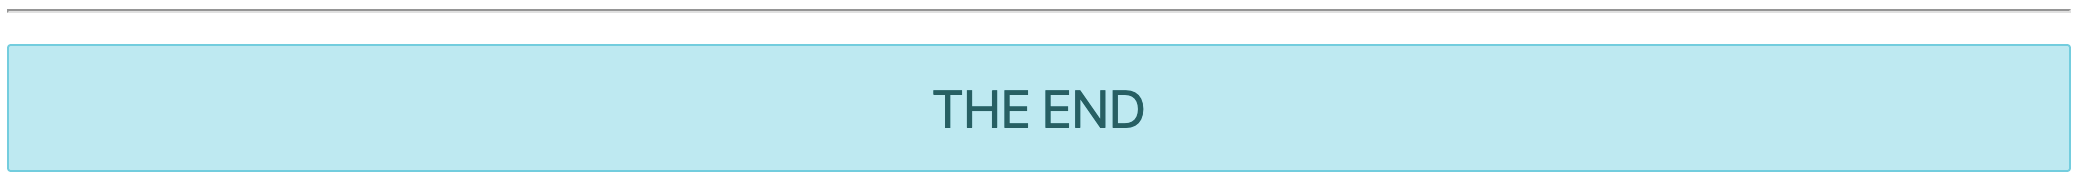